# Robustness of the spectator-ZZ fit and extrapolated memory kernel

**Purpose:** assess fit-window sensitivity, predict held-out late-time tomography, and propagate measurement shot noise into the regular transverse kernel through 400 µs. The four figure datasets end at **147 µs**. Everything beyond that boundary is a model-based extrapolation.

The primary datasets are the four Brussels runs selected in `PMME_kernel_visualize.ipynb` (main qubit 49; spectators 48, 50, 55; May 5, 2025, 16:59–17:23).

Numerical helpers are in `src/zz_robustness.py`. Calculated CSV data are written to `results/zz_robustness/`; figures remain embedded in this notebook.

In [42]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import zz_robustness as zr

DATA_DIR = Path('results/single_qubit_tomography/ibm_brussels/2025-05-05T16-59-57')
STATES = ('+', '-', '+i', '-i')
FILENAME = 'bloch-q[49, 48, 50, 55]-np50-gpp50-s8192.csv'
DATA_PATHS = [DATA_DIR / f'init{state},+,+,+' / FILENAME for state in STATES]
OUT = Path('results/zz_robustness')
OUT.mkdir(parents=True, exist_ok=True)
CUTOFFS = (60., 90., 120., 147.)
FULL_CUTOFF = CUTOFFS[-1]
KERNEL_REFERENCE_TIME = 147.  # Dominant-mode diagnostic only
FIT_SEED = 230519
N_STARTS = 16
N_BOOT = 1000  # bootstrap samples for each full-data fit
SEED = 42
GRID = np.linspace(0, 400, 801)
COLORS = dict(zip(CUTOFFS, ('tab:purple', 'tab:blue', 'tab:orange', 'tab:green')))
STATE_LABELS = {'+': r'$|+\rangle$', '-': r'$|-\rangle$', '+i': r'$|+i\rangle$', '-i': r'$|-i\rangle$'}
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'text.usetex': False})
datasets = zr.load_data(DATA_PATHS)
MEASURED_END = datasets[0].t[-1]
print(f'{len(datasets)} preparations; fitting cutoffs {CUTOFFS}; output: {OUT}')

4 preparations; fitting cutoffs (60.0, 90.0, 120.0, 147.0); output: results/zz_robustness


## Protocol fixed before validation

- Dataset paths, fitting cutoffs, random seeds, and the kernel diagnostic reference time are selected in the configuration cell above. The loader reads times from each CSV and shots/preparations from its path, and validates the three-equatorial-spectator model assumption.
<br><br>
- Independent fits for each preparation, matching the existing figure code. 
<br><br>
- Three independent spectators with zero initial $Z$ polarization. Parameter order is ``(gamma_phi0, Gamma1, Gamma2, Gamma3, gamma_down0, J1, J2, J3, omega0)``. Spectator **Gamma values are relaxation rates**. Main transverse baseline is `a = -2 gamma_phi0 - gamma_down0/2 + i omega0`.
<br><br>
- One shared GKLS baseline is fitted across all four preparations for each cutoff. The ZZ model is fitted separately to each preparation. 
<br><br>
- Fits use bounded nonlinear least squares with fixed, data-independent starting points. Solutions are selected by training loss only.
<br><br>
- Fits use data through 60, 90, 120, or 147 µs. All later measured points are held out. Bloch predictions compare the first three cutoffs; kernel window sensitivity also includes the 147 µs full-data reference.
<br><br>
- Bootstrap uncertainty is computed only for the full 147 µs fit. Each training-time/Pauli setting is resampled from its empirical binomial counts and the model is refitted.
<br><br>
- Bands are **95% pointwise percentile intervals** from measurement-level bootstrap fits. They include shot noise conditional on this model and run, not drift, calibration uncertainty, SPAM bias, or model misspecification.
<br><br>
- The model contains multiple oscillatory and decay modes; a single fitted frequency is not assumed.


In [43]:
for d in datasets:
    print(f'{d.label}: {len(d.t)} time points, {d.t[0]:g}–{d.t[-1]:g} µs, {d.shots} shots per Pauli measurement.')
print('All means match integer counts; saved errors match sqrt((1-v²)/shots).')

Loaded four preparations with 50 time points from 0 to 147 µs and 8192 shots per Pauli measurement.
All 600 Pauli mean/count entries lie on the 8192-shot integer lattice; saved errors match sqrt((1-v²)/8192).


## Kernel convention and numerical verification

The parity-space coherence generator has block form `M = [[a,b],[c,C]]` and initial coordinates `(1,0,…,0)` for equatorial spectators. Eliminating hidden coordinates gives the exact regular kernel

$$k_{2,\mathrm{reg}}(t)=b e^{Ct}c,\qquad \widetilde{k}_{2,\mathrm{reg}}(s)=b(sI-C)^{-1}c=s-a-1/\widetilde{\xi}_2(s).$$

This is equivalent to analytic inverse Laplace transformation and avoids forming an ill-conditioned numerator polynomial. Eigen decomposition is checked against direct matrix exponentiation; near degeneracy we fall back to matrix exponentiation.

Relative to the shared GKLS eigenvalue, the full kernel is
$$k_2(t)=[a-\lambda_2^{\mathrm{GKLS}}]\delta(t)+k_{2,\mathrm{reg}}(t).$$
The figures show only the regular function (µs⁻²). Changing the baseline for fixed ZZ dynamics changes the instantaneous delta term, not the regular long-time kernel.

In [44]:
print(zr.numerical_checks())
from src import zz_crosstalk as original_zz, lindblad as original_gkls
import jax.numpy as jnp
test_theta = np.array([.002,.001,.11,.23,.008,.025,-.045,.07,.035])
test_t = np.linspace(0,400,81)
for d in datasets:
    config = {'bloch-main': jnp.array(d.initial), 'z-spec': jnp.zeros(3)}
    np.testing.assert_allclose(zr.predict(test_theta,test_t,d.initial), np.asarray(original_zz.bloch_from_parameters(jnp.array(test_t),config,jnp.array(test_theta),3)), atol=2e-12)
    g = np.array([.002,.008,.035])
    np.testing.assert_allclose(zr.predict(g,test_t,d.initial,'GKLS'), np.asarray(original_gkls.bloch_from_parameters(jnp.array(test_t),jnp.array(d.initial),jnp.array(g))), atol=2e-12)
# The existing notebook's first cell contains only imports and the kernel function.
legacy_notebook = json.loads(Path('notebook/PMME_kernel_visualize.ipynb').read_text())
legacy_scope = {}
exec(''.join(legacy_notebook['cells'][0]['source']), legacy_scope)
old_kernel = legacy_scope['analytical_memory_kernel'](test_t, {'z-spec':np.zeros(3)},test_theta,3)
np.testing.assert_allclose(zr.kernel(test_theta,test_t,reference_time=KERNEL_REFERENCE_TIME)[0],old_kernel,atol=1e-9,rtol=1e-6)
print('Also passed: equivalence to existing ZZ/GKLS forward models for all four preparations and existing polynomial/residue kernel on a nondegenerate parameter set.')

Passed: analytic Jacobian, full matrix dynamics, Laplace identity, direct expm, single/zero spectator limits, large-rate stability.
Also passed: equivalence to existing ZZ/GKLS forward models for all four preparations and existing polynomial/residue kernel on a nondegenerate parameter set.


In [45]:
fits, scores, _ = zr.fit_windows(datasets, CUTOFFS, n_starts=N_STARTS, seed=FIT_SEED)
scores.to_csv(OUT/'fit_and_validation_scores.csv',index=False)
shared_gkls = pd.DataFrame([dict(cutoff=cutoff, mse=fits[datasets[0].label,cutoff,'GKLS']['mse'], gamma_phi=fits[datasets[0].label,cutoff,'GKLS']['theta'][0], gamma_down=fits[datasets[0].label,cutoff,'GKLS']['theta'][1], omega0=fits[datasets[0].label,cutoff,'GKLS']['theta'][2]) for cutoff in CUTOFFS])
shared_gkls.to_csv(OUT/'shared_gkls_parameters.csv',index=False)
parameter_rows, kernel_curves, kernel_diagnostics = [], {}, []
for d in datasets:
    for cutoff in CUTOFFS:
        z, g = fits[d.label,cutoff,'ZZ'], fits[d.label,cutoff,'GKLS']
        k, diag = zr.kernel(z['theta'], GRID, reference_time=KERNEL_REFERENCE_TIME)
        kernel_curves[d.label,cutoff] = k
        delta = zr.baseline(z['theta'])-zr.baseline(g['theta'],'GKLS')
        parameter_rows.append(dict(state=d.label,cutoff=cutoff,mse=z['mse'],converged=z['success'],jacobian_condition=z['jacobian_condition'],delta_real=delta.real,delta_imag=delta.imag,**dict(zip(zr.PARAMETERS,z['theta']))))
        kernel_diagnostics.append(dict(state=d.label,cutoff=cutoff,**diag))
parameters = pd.DataFrame(parameter_rows)
parameters.to_csv(OUT/'fitted_parameters_and_baseline.csv',index=False)
print('Completed ZZ fits and shared GKLS fits for all time windows.')
assert parameters.converged.all(), 'Resolve primary-fit convergence before interpreting bootstrap bands.'

 +, cutoff 60: ZZ train MSE 0.000130593
 -, cutoff 60: ZZ train MSE 0.000186919
+i, cutoff 60: ZZ train MSE 0.000141077
-i, cutoff 60: ZZ train MSE 0.000123231
 +, cutoff 90: ZZ train MSE 0.000144812
 -, cutoff 90: ZZ train MSE 0.000199099
+i, cutoff 90: ZZ train MSE 0.000147348
-i, cutoff 90: ZZ train MSE 0.000109918
 +, cutoff 120: ZZ train MSE 0.000129712
 -, cutoff 120: ZZ train MSE 0.000184488
+i, cutoff 120: ZZ train MSE 0.000147078
-i, cutoff 120: ZZ train MSE 0.000107416
 +, cutoff 147: ZZ train MSE 0.000152169
 -, cutoff 147: ZZ train MSE 0.000175585
+i, cutoff 147: ZZ train MSE 0.000149808
-i, cutoff 147: ZZ train MSE 0.000119508
Completed ZZ fits and shared GKLS fits for all time windows.


## Held-out predictions

Dots are measured means with one-standard-error bars. Solid curves are ZZ predictions; dotted curves use the shared GKLS baseline fitted across all four preparations. The orange background is held out.

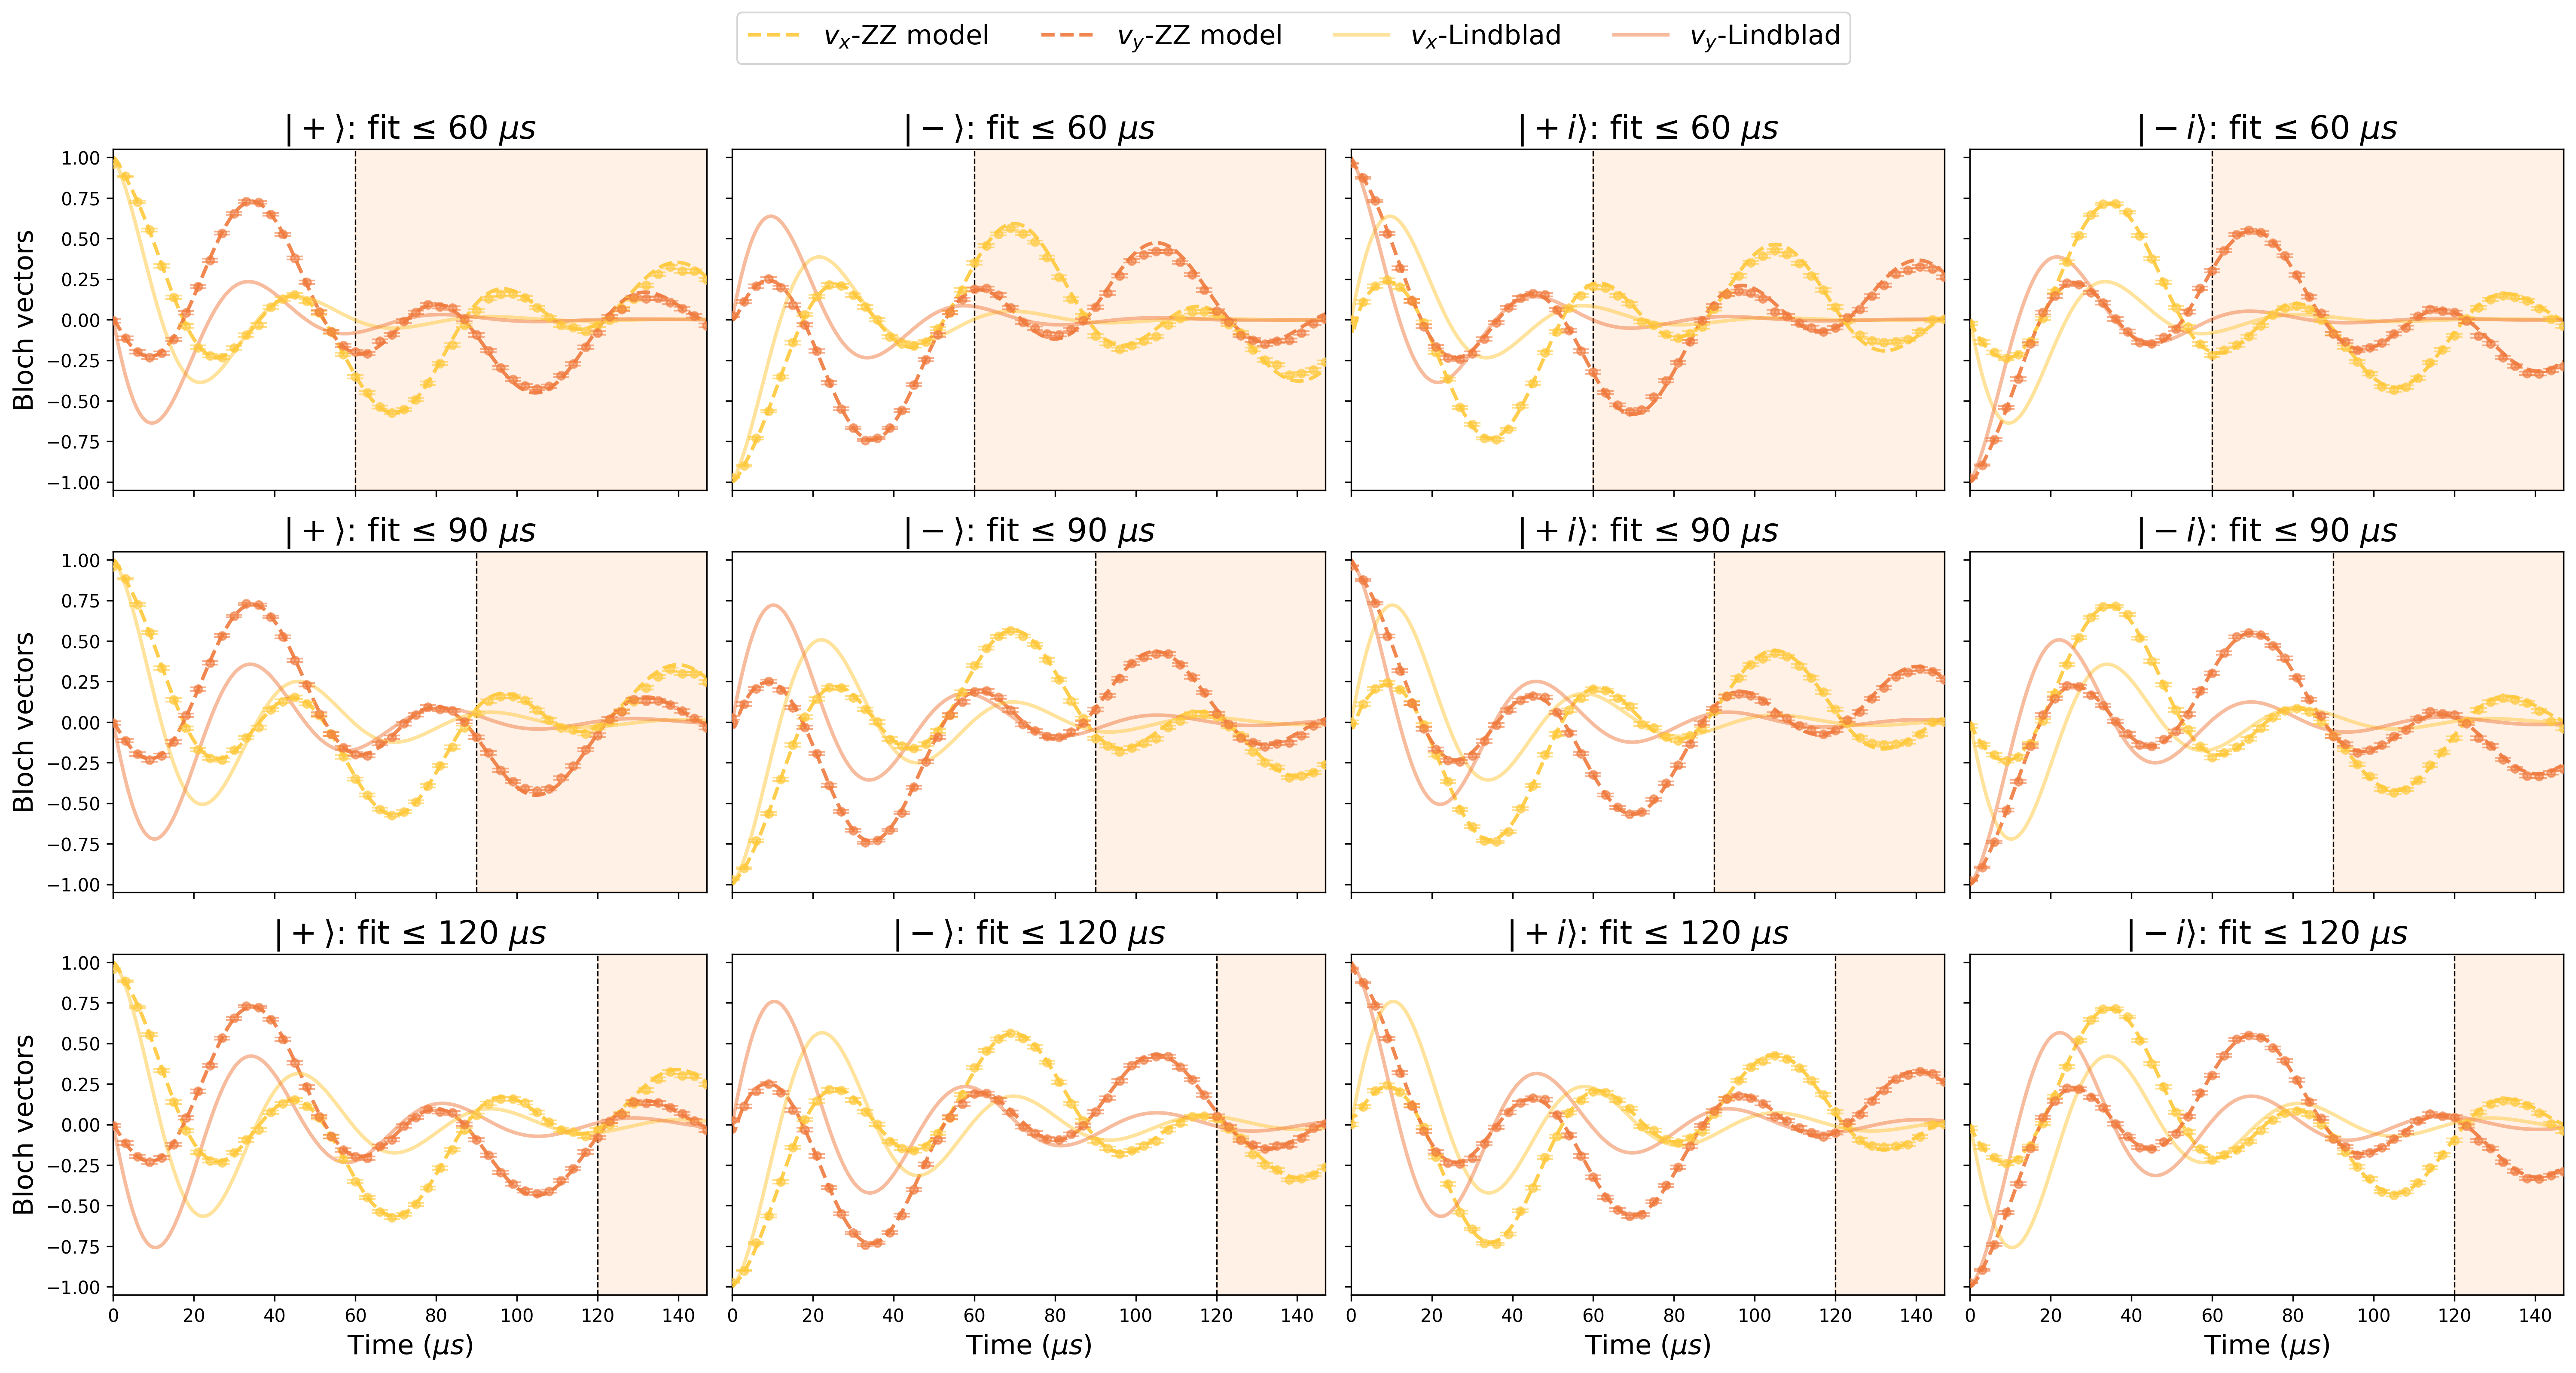

In [55]:
fig, axes = plt.subplots(3,4,figsize=(20,10.5),sharex=True,sharey=True, dpi=300)
fine = np.linspace(0, MEASURED_END, 500)
prediction_datasets = [next(d for d in datasets if d.label == state) for state in STATES]
for row,cutoff in enumerate(CUTOFFS[:-1]):
    for col,d in enumerate(prediction_datasets):
        ax=axes[row,col]
        ax.axvspan(cutoff,MEASURED_END,color='tab:orange',alpha=.10)
        ax.axvline(cutoff,color='k',ls='--',lw=.8)
        z=zr.predict(fits[d.label,cutoff,'ZZ']['theta'],fine,d.initial)
        g=zr.predict(fits[d.label,cutoff,'GKLS']['theta'],fine,d.initial,'GKLS')
        for q,color in enumerate(["#ffc93c","#f07b3f"]):
            ax.errorbar(d.t,d.y[q],yerr=d.se[q],ls="",ms=4.5,color=color,alpha=.6,capsize=4.5,marker="o",elinewidth=.8,zorder=3,label='_nolegend_')
        for q,color in enumerate(["#ffc93c","#f07b3f"]): ax.plot(fine,z[q],color=color,ls='--',lw=2, alpha=0.9,label=(r'$v_x$-ZZ model',r'$v_y$-ZZ model')[q])
        for q,color in enumerate(["#ffc93c","#f07b3f"]): ax.plot(fine,g[q],color=color,alpha=0.5,lw=2, label=(r'$v_x$-Lindblad',r'$v_y$-Lindblad')[q])
        ax.set_title(rf'{STATE_LABELS[d.label]}: fit ≤ {cutoff:g} $\mu s$', fontsize=18)
        ax.set_xlim(0,MEASURED_END); ax.set_ylim(-1.05,1.05)
        if col == 0:
            ax.set_ylabel('Bloch vectors', fontsize=15)
for ax in axes[-1]: ax.set_xlabel(r'Time ($\mu s$)', fontsize=15)
handles,labels=axes[0,0].get_legend_handles_labels()
fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(.5,1.02),ncol=4,fontsize=15)
fig.tight_layout(rect=(0,0,1,.95))
# plt.show()
plt.savefig("images/bloch_extrapolation.pdf", bbox_inches='tight', dpi=300)

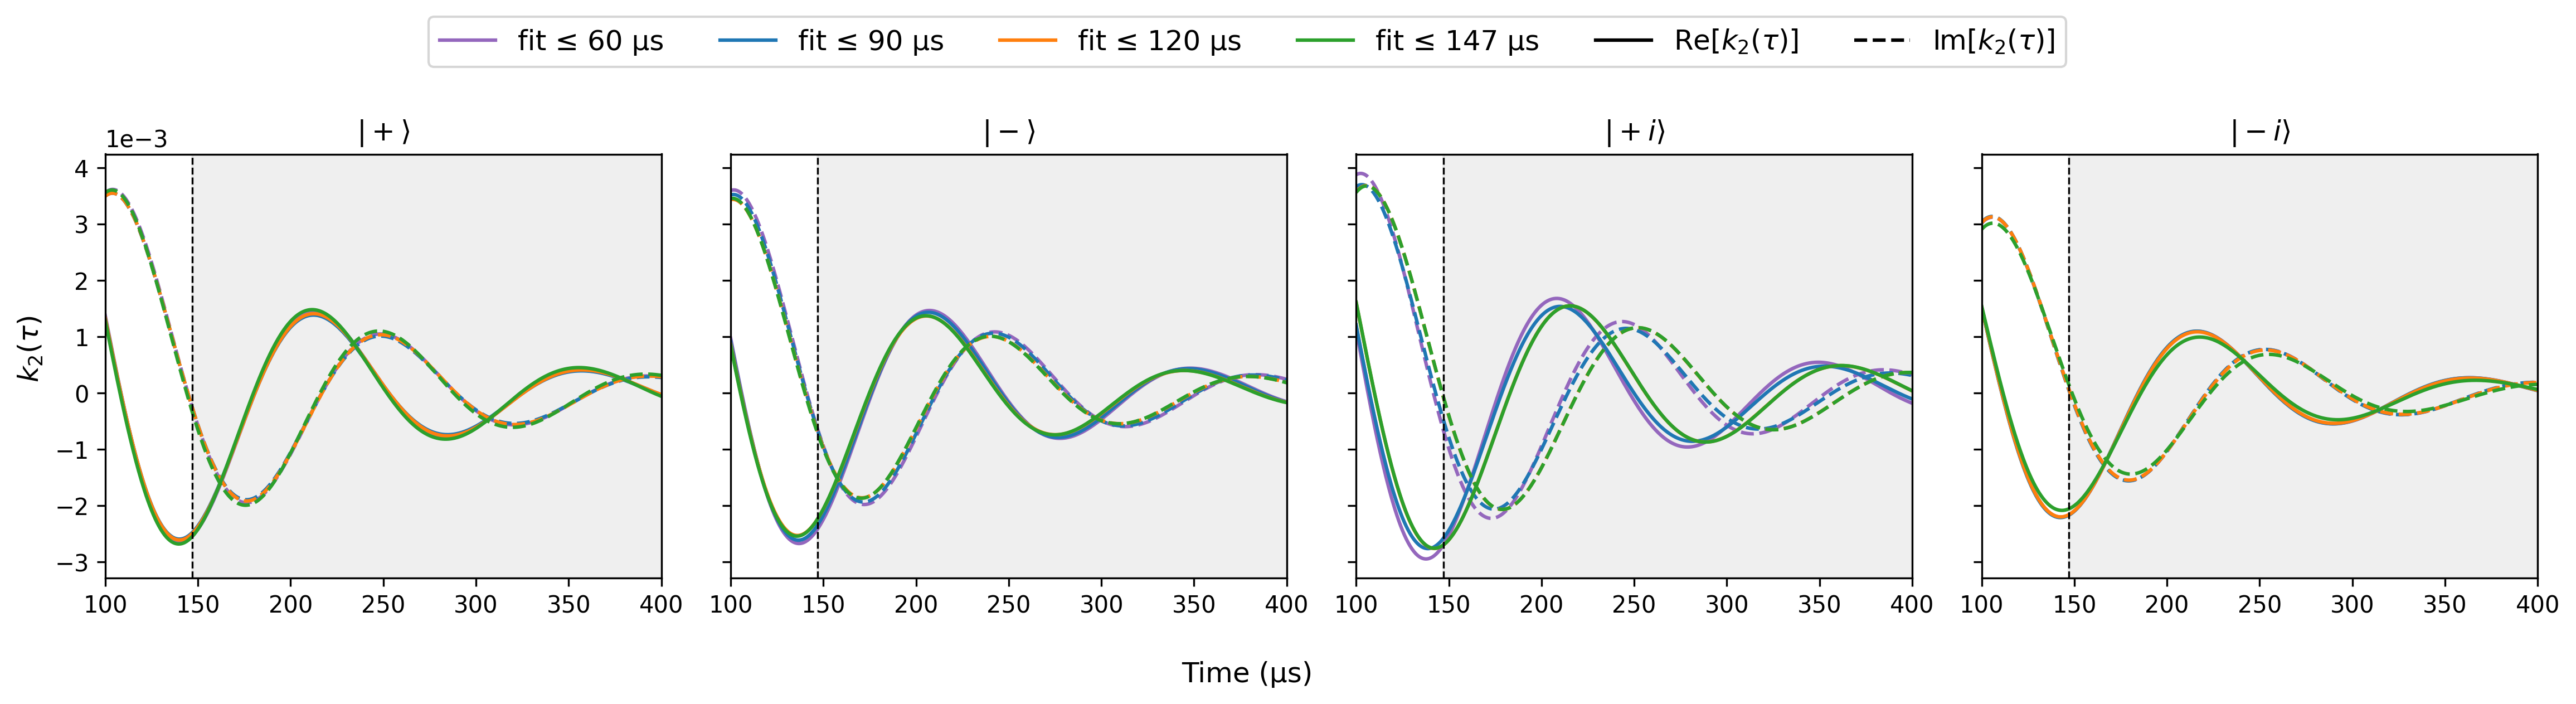

In [ ]:
fig,axes=plt.subplots(1,4,figsize=(16,4.5),sharex=True,sharey=True,dpi=300)
stability_rows=[]
plot_mask=GRID>=100
for row,d in enumerate(datasets):
    ref=kernel_curves[d.label,FULL_CUTOFF]
    ax=axes[row]
    for cutoff in CUTOFFS:
        curve=kernel_curves[d.label,cutoff]
        ax.plot(GRID[plot_mask],curve.real[plot_mask],color=COLORS[cutoff],label=rf'fit ≤ {cutoff:g} $\mu s$')
        ax.plot(GRID[plot_mask],curve.imag[plot_mask],color=COLORS[cutoff],ls='--')
    ax.axvspan(MEASURED_END,GRID[-1],color='gray',alpha=.12); ax.axvline(MEASURED_END,color='k',ls='--',lw=.8)
    ax.set_xlim(100,400)
    ax.set_title(STATE_LABELS[d.label], fontsize=12); ax.ticklabel_format(axis='y',style='sci',scilimits=(0,0))
    for cutoff in CUTOFFS[:-1]:
        for region,mask in [('measured_support',GRID<=MEASURED_END),('extrapolation',GRID>MEASURED_END)]:
            diff=kernel_curves[d.label,cutoff][mask]-ref[mask]
            stability_rows.append(dict(state=d.label,cutoff=cutoff,region=region,
                                       complex_rms_difference=np.sqrt(np.mean(abs(diff)**2)),
                                       relative_l2_difference=np.linalg.norm(diff)/np.linalg.norm(ref[mask])))
axes[0].plot([],[],color='k',label=r'$\mathrm{Re}[k_2(\tau)]$')
axes[0].plot([],[],color='k',ls='--',label=r'$\mathrm{Im}[k_2(\tau)]$')
handles,labels=axes[0].get_legend_handles_labels()
fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(.5,.96),ncol=7,fontsize=12)
fig.supxlabel(r'Time ($\mu s$)',y=.05, fontsize=12); fig.supylabel(r'$k_2(\tau)$',x=0.04, fontsize=12)
fig.tight_layout(rect=(.025,.04,1,.84))

stability=pd.DataFrame(stability_rows)
stability.to_csv(OUT/'kernel_window_sensitivity.csv',index=False)

# plt.show()
plt.savefig("images/kernel_window_sensitivity.pdf", bbox_inches='tight', dpi=300)

## Measurement-level bootstrap

The observed means pass the exact count-lattice and standard-error checks. Resampling therefore uses the recovered integer counts rather than a Gaussian approximation. Only training-time measurements enter each bootstrap. Zero-rate boundaries and nonlinear parameter correlations are retained.

Bootstrap samples are kept in memory only. Failed selected fits remain NaN and are counted below. No trimming of extreme but finite kernel curves is performed.

In [48]:
boot,boot_records={},[]
cutoff=FULL_CUTOFF
for state_index,d in enumerate(datasets):
    arrays, records = zr.bootstrap(
        d, cutoff, fits[d.label, cutoff, 'ZZ'], GRID, count=N_BOOT,
        seed=SEED+100*state_index+2, fit_seed=FIT_SEED, n_starts=N_STARTS,
        reference_time=KERNEL_REFERENCE_TIME,
    )
    boot[d.label,cutoff]=arrays
    boot_records.append(records)
boot_diagnostics=pd.concat(boot_records,ignore_index=True)
success=boot_diagnostics.groupby(['state','cutoff']).agg(attempted=('replicate','size'),zz_success=('zz_success','sum'),kernel_success=('kernel_success','sum'),max_eigenvector_condition=('eigenvector_condition','max'))
print(f'Bootstrap kernel reconstructions completed: {int(success.kernel_success.sum())}/{int(success.attempted.sum())}.')
if (success.kernel_success < success.attempted).any(): print('Some replicates failed: all percentile summaries below explicitly condition on successful refits. See diagnostics before interpretation.')

 + 147: 100/1000, 6s
 + 147: 200/1000, 11s
 + 147: 300/1000, 16s
 + 147: 400/1000, 22s
 + 147: 500/1000, 27s
 + 147: 600/1000, 33s
 + 147: 700/1000, 38s
 + 147: 800/1000, 44s
 + 147: 900/1000, 50s
 + 147: 1000/1000, 55s
 - 147: 100/1000, 6s
 - 147: 200/1000, 12s
 - 147: 300/1000, 18s
 - 147: 400/1000, 25s
 - 147: 500/1000, 31s
 - 147: 600/1000, 37s
 - 147: 700/1000, 44s
 - 147: 800/1000, 52s
 - 147: 900/1000, 59s
 - 147: 1000/1000, 64s
+i 147: 100/1000, 5s
+i 147: 200/1000, 10s
+i 147: 300/1000, 15s
+i 147: 400/1000, 21s
+i 147: 500/1000, 25s
+i 147: 600/1000, 30s
+i 147: 700/1000, 35s
+i 147: 800/1000, 39s
+i 147: 900/1000, 44s
+i 147: 1000/1000, 49s
-i 147: 100/1000, 5s
-i 147: 200/1000, 10s
-i 147: 300/1000, 15s
-i 147: 400/1000, 20s
-i 147: 500/1000, 24s
-i 147: 600/1000, 30s
-i 147: 700/1000, 34s
-i 147: 800/1000, 38s
-i 147: 900/1000, 43s
-i 147: 1000/1000, 49s
Bootstrap kernel reconstructions completed: 4000/4000.


In [49]:
band_rows,mc_rows=[],[]
cutoff=FULL_CUTOFF
for d in datasets:
    arrays=boot[d.label,cutoff]
    for component in ['real','imag']:
        values=getattr(arrays['kernel'],component)
        lo,med,hi=np.nanpercentile(values,[2.5,50,97.5],axis=0)
        point=getattr(kernel_curves[d.label,cutoff],component)
        for j,t in enumerate(GRID): band_rows.append(dict(state=d.label,cutoff=cutoff,component=component,t_us=t,estimate=point[j],lower=lo[j],median=med[j],upper=hi[j]))
        half=np.nanpercentile(values[:N_BOOT//2],[2.5,97.5],axis=0)
        mask=GRID>MEASURED_END
        mc_rows.append(dict(state=d.label,component=component,endpoint_change_over_width=np.sqrt(np.mean((half[:,mask]-np.array([lo,hi])[:,mask])**2))/np.sqrt(np.mean((hi[mask]-lo[mask])**2))))
bands=pd.DataFrame(band_rows); bands.to_csv(OUT/'kernel_pointwise_bands.csv',index=False)
mc=pd.DataFrame(mc_rows)

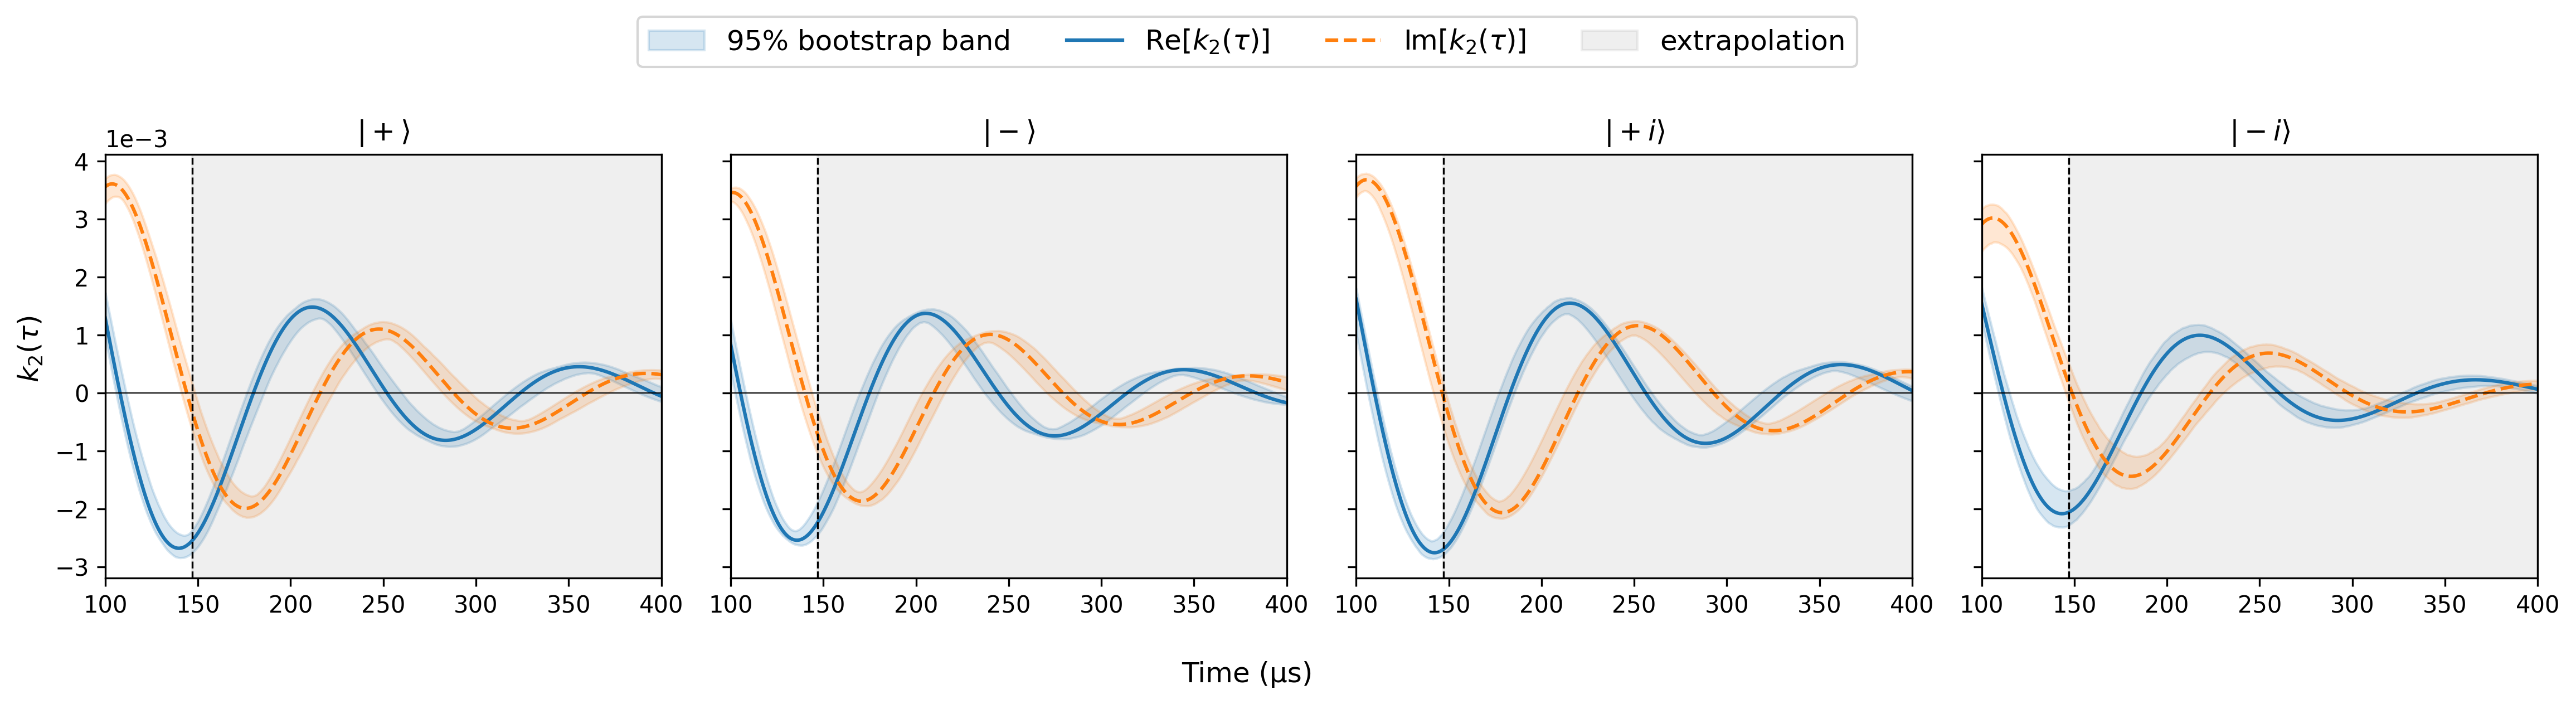

In [50]:
# Bootstrap uncertainty for the fit to all measured data.
cutoff=FULL_CUTOFF
fig,axes=plt.subplots(1,4,figsize=(16,4.5),sharex=True,sharey=True,dpi=300)
for row,d in enumerate(datasets):
    ax=axes[row]
    for component,color,linestyle,label in [('real','tab:blue','-',r'$\mathrm{Re}[k_2(\tau)]$'),('imag','tab:orange','--',r'$\mathrm{Im}[k_2(\tau)]$')]:
        frame=bands[(bands.state==d.label)&(bands.cutoff==cutoff)&(bands.component==component)&(bands.t_us>=100)]
        ax.fill_between(frame.t_us,frame.lower,frame.upper,color=color,alpha=.18,label='95% bootstrap band' if component=='real' else '_nolegend_')
        ax.plot(frame.t_us,frame.estimate,color=color,ls=linestyle,label=label)
    ax.axvspan(MEASURED_END,GRID[-1],color='gray',alpha=.12,label='extrapolation')
    ax.axvline(MEASURED_END,color='k',ls='--',lw=.8)
    ax.axhline(0,color='k',lw=.5); ax.set_xlim(100,400)
    ax.set_title(STATE_LABELS[d.label], fontsize=12)
    ax.ticklabel_format(axis='y',style='sci',scilimits=(0,0))
handles,labels=axes[0].get_legend_handles_labels()
fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(.5,.96),ncol=4,fontsize=12)
fig.supxlabel('Time (µs)',y=.05, fontsize=12); fig.supylabel(r'$k_2(\tau)$',x=.04, fontsize=12)
fig.tight_layout(rect=(.025,.04,1,.84))
# plt.show()
plt.savefig("images/bootstrap_kernel_bands.pdf", bbox_inches='tight', dpi=300)

In [51]:
held=scores[(scores.split=='held_out') & (scores.model=='ZZ')]
print(f'Bootstrap successful kernels: {int(success.kernel_success.sum())}/{int(success.attempted.sum())}')
print('Calculated data saved to',OUT)

Bootstrap successful kernels: 4000/4000
Calculated data saved to results/zz_robustness
